In [12]:
#question 5.2
import numpy as np

data = np.loadtxt('12.txt', comments = '#')
x = data[:,0]; y = data[:,1]
print(f"x is {x}")
print(f"y is {y}")
print(f"{np.max(x)} is the max of x, {np.min(x)} is the min of x, and {np.mean(x)} is the mean of x!")
print(f"{np.max(y)} is the max of y, {np.min(y)} is the min of y, and {np.mean(y)} is the mean of y!")

y2 = (y - np.median(y))**2
print(y2)

x is [1. 2. 4. 7. 1. 9. 1. 7. 6. 2.]
y is [2. 5. 4. 3. 0. 8. 1. 7. 7. 0.]
9.0 is the max of x, 1.0 is the min of x, and 4.0 is the mean of x!
8.0 is the max of y, 0.0 is the min of y, and 3.7 is the mean of y!
[ 2.25  2.25  0.25  0.25 12.25 20.25  6.25 12.25 12.25 12.25]


In [2]:
#5.6
import numpy as np

a = np.array([1, 2, 3])
b = np.array([4, 5, 6])
print(np.concatenate((a, b)))
#the result is a 1D array which zips the arrays a and b together

a = np.array([[1, 2], [3, 4]])
b = np.array([[5, 6], [7, 8]])
print(np.concatenate((a, b)))
#this prints a 2D array which is a concatenation of a and b 
print(np.concatenate((a, b), axis=0))
#this prints a 2D array which is a concatenation of a and b, axis = 0 is the default option, and just adds the arrays 'normally'

print(np.concatenate((a,b), axis=1))
#this forces the concatenation to occur across the 'first' axis, which is the vertical axis. If you were to make a matrix out of the arrays within a and b, the first 'column' would be axis along which the arrays are joined 

#axis = None smushes the two together into a 1d array


[1 2 3 4 5 6]
[[1 2]
 [3 4]
 [5 6]
 [7 8]]
[[1 2]
 [3 4]
 [5 6]
 [7 8]]
[1 2 3 4 5 6 7 8]


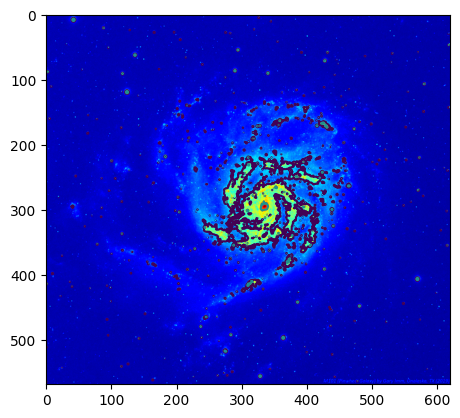

(568, 620)


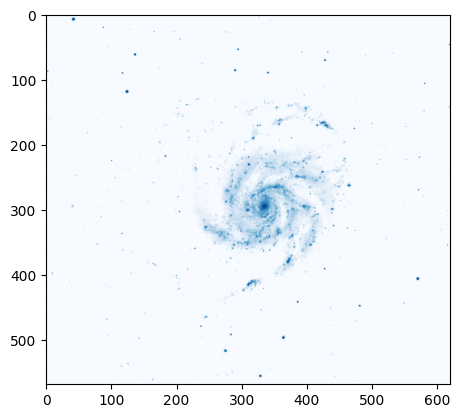

In [9]:
import imageio.v2 as imo
import matplotlib.pyplot as plt
import numpy as np
import numpy.ma as ma
im =imo.imread('m101BW.jpg')
plt.imshow(im, cmap = 'jet')
levels = np.sort([100, 200, 300])
plt.contour(im, levels)
plt.show()



print(np.shape(im))
c = np.percentile(im, 90)
cd = ma.mask_rowcols(im>c, axis = None)
a = np.where(im>c, im, c)
plt.imshow(a, cmap = 'Blues')


[0.00482 0.00666 0.00705 0.00889 0.01269 0.02012 0.02789 0.03712 0.03985
 0.04617 0.0606  0.04935 0.02734 0.01746 0.0149  0.0247  0.03478 0.03472
 0.03174 0.02931 0.02995 0.02909 0.02687 0.0247  0.02483 0.02504 0.02486
 0.0228  0.01888 0.01625 0.01589 0.01473 0.01294 0.01236 0.01144 0.01118
 0.01038 0.00848 0.00751 0.0072 ]
0.0606 is the max, 0.00482 is the min, 0.0222885 is the mean, 0.89154 is the sum, 0.012699434544498428 is the standard deviation


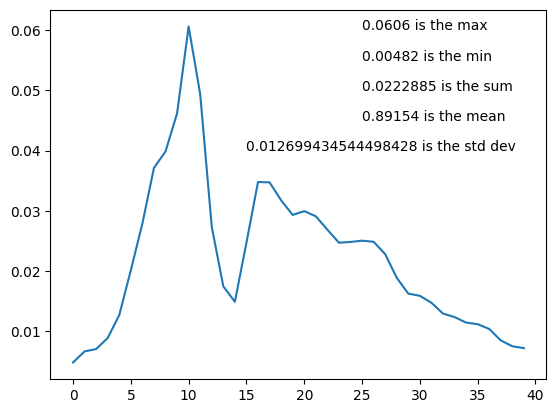

In [45]:
#question 5.10
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt('ngc6946.txt', comments = '#')
b = data.reshape(40, 50, 70) #reshapes the 1d array into a data cube
res = b[:, 25, 35] #slices 3d array along the 25th row, 35th column to show the z-profile 
print(res)
a, c, d, e, f = np.max(res), np.min(res), np.mean(res), np.sum(res), np.std(res)
print(f"{a} is the max, {c} is the min, {d} is the mean, {e} is the sum, {f} is the standard deviation")

plt.plot(res)
plt.text(25, 0.06, f'{a} is the max')
plt.text(25, 0.055, f'{c} is the min')
plt.text(25, 0.05,f'{d} is the sum')
plt.text(25, 0.045,f'{e} is the mean')
plt.text(15, 0.04,f'{f} is the std dev')
plt.show()

[0.0023294400000000003, 0.013887463779452956, 0.02544548755890591]


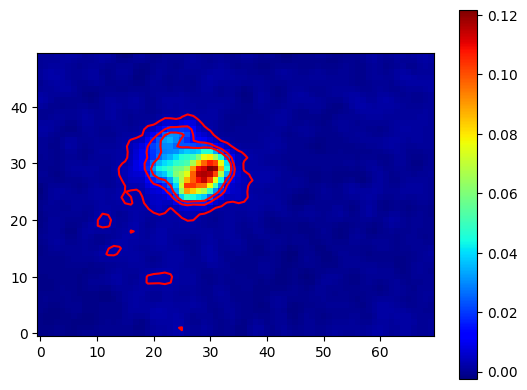

In [1]:
#question 5.11
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt('ngc6946.txt', comments = '#')
b = data.reshape(40, 50, 70) #reshapes the 1d array into a data cube
res = b[0]
mean = np.mean(res)
std = np.std(res)

levels = [mean, mean+std, mean+2*std]
print(levels)
plt.imshow(res, origin = 'lower', cmap = 'jet')
plt.colorbar()
plt.contour(res, levels, colors = 'red')
plt.show()



In [6]:
from scipy.constants import c


class Galaxy:    
    """Class for redshift calculation of galaxies"""  
    c_ = c
    caH_0 = 3968.5      # Calcium H line in rest frame
    s_l = c
    def __init__(self, name, calciumHline=caH_0, c=c):
        self.name = name
        self.caH = calciumHline
        self.c = c
    def redshift(self):        
        z = (self.caH - self.caH_0)/self.caH
        return z
    def velocity(self):
        v = self.redshift()*self.c_*10**(-3)
        return v
    
gal2 = Galaxy("NGC1832", 3994.7)
z = gal2.redshift()
print(z)
v = gal2.velocity()
print(v)

0.0065586902646005505
1966.2458756852695


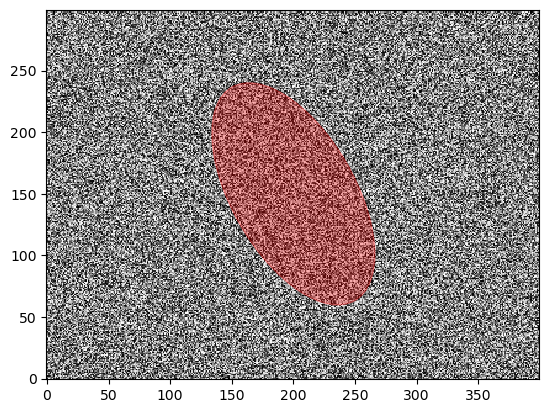

In [50]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as pth



Nx = 400
Ny = 300
data = np.random.random((Ny,Nx))
fig, ax = plt.subplots(1)
plt.imshow(data, interpolation='none', origin="lower", cmap='gray')
a = pth.Ellipse((Nx/2, Ny/2), 100, 200, angle = 30, color = 'r', alpha = 0.3)
ax.add_patch(a)